# Numerical Simulation Laboratory (NSL) 
## Numerical exercises 5 

In quantum physics a **wave function**, $\Psi$, is a mathematical description of the state of a quantum system. The wave function is a complex-valued probability amplitude, and the probabilities for the possible results of measurements made on the system can be derived from it.

For now on, let's consider the simple case of a non-relativistic single particle, without spin, in three spatial dimensions. The state of such a particle is completely described by its wave function, $\Psi(\vec{r},t)$, where $\vec{r}$ is position and $t$ is time.

For one spinless particle, if the wave function is interpreted as a probability amplitude, the square modulus of the wave function, $|\Psi(\vec{r},t)|^2$, is interpreted as the probability density that the particle is at $\vec{r}$ at time $t$. Once we have a probability density, we can use Monte Carlo ...

#### Hydrogen atom
The wave functions of the eigenstates of an electron in a Hydrogen atom (this is the only atom for which the Schroedinger equation has been solved exactly) are expressed in terms of spherical harmonics and generalized Laguerre polynomials. It is convenient to use spherical coordinates, and the wave function can be separated into functions of each coordinate:

$$
\Psi_{n,l,m}(r,\theta,\phi)=
\sqrt{\left(\frac{2}{na_0}\right)^3 \frac{(n-l-1)!}{2n[(n+l)!]}}
e^{-r/na_0}\left(\frac{2r}{na_0}\right)^l L_{n-l-1}^{2l+1}\left(\frac{2r}{na_0}\right)
Y_l^m(\theta,\phi)
$$

where $a_0=4\pi\epsilon_0\hbar^2/m_e e^2=0.0529$ nm is the Bohr radius, $L_{n-l-1}^{2l+1}$ are the generalized Laguerre polynomials of degree $n-l-1$, $n=1,2,...$ is the principal quantum number, $l=0,1, ..., n-1$ the azimuthal quantum number, $m=-l, -l+1, ..., l-1, l$ the magnetic quantum number.

For example, the ground state wave function is:
$$
\Psi_{1,0,0}(r,\theta,\phi)=
\frac{a_0^{-3/2}}{\sqrt{\pi}} e^{-r/a_0} 
$$
whereas one of the three $2p$ excited state is:
$$
\Psi_{2,1,0}(r,\theta,\phi)=
\frac{a_0^{-5/2}}{8}\sqrt{\frac{2}{\pi}} r e^{-r/2a_0} \cos(\theta)
$$
Expectation values for the radius turns out to be exactly:
$$
\left\langle r \right\rangle_{\Psi_{1,0,0}} = \frac{3}{2}a_0
\quad
\left\langle r \right\rangle_{\Psi_{2,1,0}} = 5 a_0
$$
</span>


### Exercise 05.1


Use the Metropolis algorithm to sample $|\Psi_{1,0,0}(x,y,z)|^2$ and $|\Psi_{2,1,0}(x,y,z)|^2$ **in Cartesian coordinates** using, initially, an uniform transition probability $T(\vec{x}|\vec{y})$. Use the sampled positions to estimate $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$. As usual, use data blocking and give an estimate of the statistical uncertainties.

Show a picture of your estimations of $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$ and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^6$) as a function of the number of blocks, $N$.

- Use Bohr radius units, $a_0$ for distances
- Choose the step of the uniform transition probability $T(\vec{x}|\vec{y})$ in order to obtain 50% of acceptance in both cases
- Choose a reasonable starting point in the 3D space and equilibrate your sampling before to start measuring the radius. What do you observe when you start very far from the origin?
- How large should be the number of Monte Carlo Metropolis steps in each block?
- If you use a multivariate normal transition probability $T(\vec{x}|\vec{y})$, i.e. a Gaussian for each coordinate, your results for $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$ are equivalent?


In [1]:
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.gridspec as gridspec

from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.special import erf
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from numpy import exp
from numpy.lib.scimath import log, sqrt

plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

color=plt.cm.inferno(0.5)
color2=plt.cm.inferno(0.2)

### Implementation
Il file main.cpp implementa il Metropolis Algorithm per campionare le distribuzioni di probabilità ( $|\Psi_{1,0,0}(x,y,z)|^2$ ) e ( $|\Psi_{2,1,0}(x,y,z)|^2$ ) in coordinate cartesiane. L'obiettivo è stimare il valore medio del raggio ( $\langle r \rangle$ ) per i due stati quantici dell'atomo di idrogeno e calcolare le incertezze statistiche utilizzando il metodo del data blocking.

#### Parametri Utilizzati

1. **Parametri generali:**
    - Numero totale di lanci: ( M = 10^6 ).
    - Numero di blocchi: ( N = 100 ).
    - Numero di passi per blocco: ( L = M / N = 10^4 ).
    - Unità di misura: Distanze espresse in unità del raggio di Bohr ( a_0 ).

2. **Distribuzioni di transizione:**
    - Uniforme: ( $T(\vec{x}|\vec{y})$ ) è una distribuzione uniforme con passo ( $\Delta x, \Delta y, \Delta z $) scelto per ottenere un tasso di accettazione del 50%.
    - Gaussiana: ( $T(\vec{x}|\vec{y})$ ) è una distribuzione normale multivariata con deviazione standard ( $\sigma$ ) scelta per ottenere un tasso di accettazione del 50%.

3. **Funzioni d'onda:**
    - Stato ( 1s ):  $\Psi_{1,0,0}(x, y, z) = \frac{1}{\sqrt{\pi}} e^{-r}$  con ( $r = \sqrt{x^2 + y^2 + z^2}$ ).
    - Stato ( 2p ): $\Psi_{2,1,0}(x, y, z) = \frac{1}{8} \sqrt{\frac{2}{\pi}} z e^{-r/2}$

4. **Punti di partenza:**
    - Vicino all'origine: ( $(x, y, z) = (0.1, 0.1, 0.1)$ ).
    - Lontano dall'origine: ( $(x, y, z) = (10.0, 10.0, 10.0)$ ).

#### Implementazione del Metropolis Algorithm
1. **Inizializzazione:**
- Le posizioni iniziali delle particelle sono fissate a ( $(x, y, z)$ ) per entrambi gli stati ( 1s ) e ( 2p ).
- I parametri del passo (( $\Delta x$ ) per la distribuzione uniforme e ( $\sigma $) per la distribuzione gaussiana) sono scelti per ottenere un tasso di accettazione del 50%.

2. **Generazione di nuove posizioni:**

Per ogni passo del Metropolis Algorithm, vengono generate nuove posizioni ( $(x', y', z')$ ) utilizzando:
- Distribuzione uniforme: ( $x' = x + \text{Rannyu}(-\Delta x, \Delta x)$ ).
- Distribuzione gaussiana: ( $x' = x + \text{Gauss}(0, \sigma)$ ).

3. **Calcolo del rapporto di accettazione:**

- Il rapporto di accettazione è calcolato come: [$ A = \min\left(1, \frac{|\Psi(x', y', z')|^2}{|\Psi(x, y, z)|^2}\right)$ ]
- Se un numero casuale uniforme ( \xi \in [0, 1] ) è minore di ( A ), la nuova posizione ( (x', y', z') ) viene accettata; altrimenti, la particella rimane nella posizione precedente.

4. **Calcolo di ( \langle r \rangle ):**

Ad ogni passo, viene calcolato il modulo della posizione ( $r = \sqrt{x^2 + y^2 + z^2}$ ).I valori di ( r ) vengono accumulati per calcolare la media e la varianza.

5. **Data blocking:**

I ( M ) passi sono suddivisi in ( N ) blocchi.
Per ogni blocco, viene calcolata la media ( $\langle r \rangle$ ) e la varianza.
Le medie progressive e le incertezze sono calcolate utilizzando:  $\text{Errore} = \sqrt{\frac{\langle r^2 \rangle - \langle r \rangle^2}{n}} $

#### Output Generato
1. File di output:

Posizioni campionate:
 - positions_1s_uniform.data, positions_1s_gauss.data: Posizioni campionate per lo stato ( 1s ).
 - positions_2p_uniform.data, positions_2p_gauss.data: Posizioni campionate per lo stato ( 2p ).

Medie e incertezze:
 - output_average_1s_uniform.data, output_average_1s_gauss.data: Medie e incertezze per ( $\langle r \rangle $) nello stato ( 1s ).
 - output_average_2p_uniform.data, output_average_2p_gauss.data: Medie e incertezze per ( $\langle r \rangle$ ) nello stato ( 2p ).

2. Stampa su terminale:

Valori finali di ( $\langle r \rangle$ ) e tassi di accettazione per ciascuna configurazione.

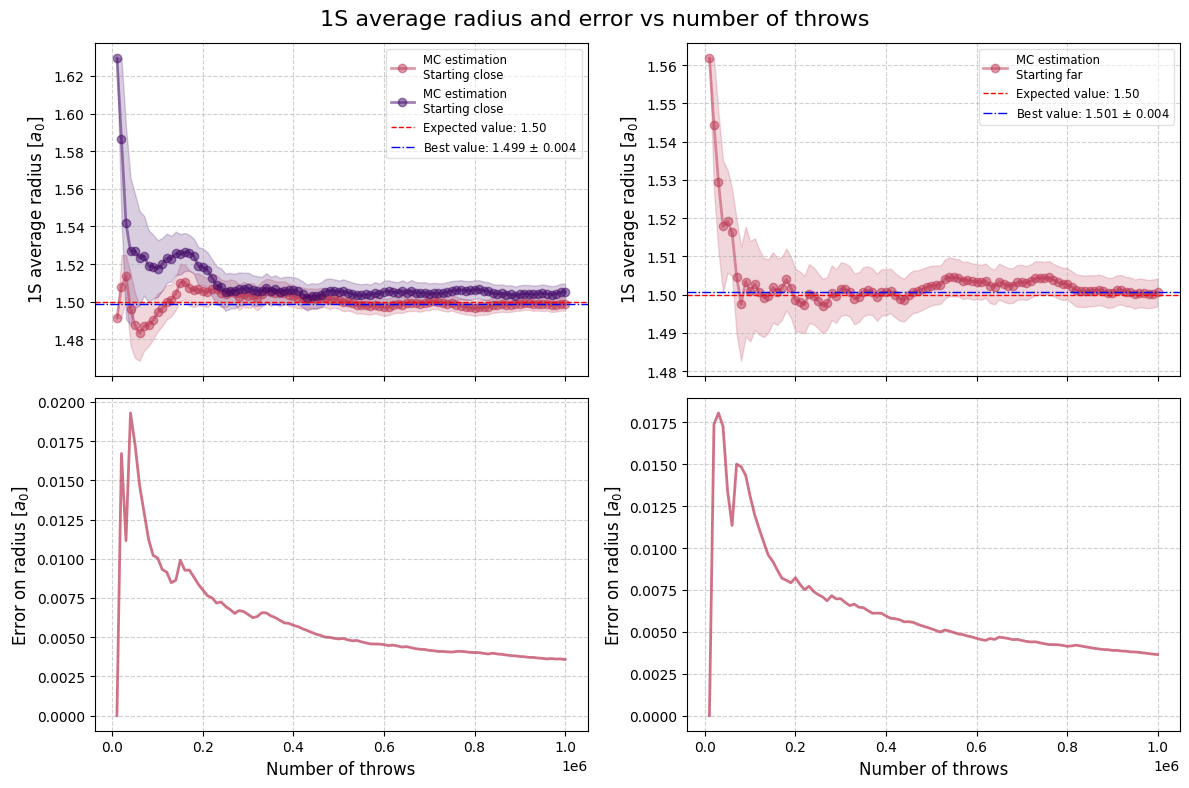

In [2]:
x_1s, y_1s, error_1s = np.loadtxt("output_average_1s_uniform.data", usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_1s_gauss, y_1s_gauss, error_1s_gauss = np.loadtxt("output_average_1s_gauss.data", usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_1s_far, y_1s_far, error_1s_far = np.loadtxt("output_average_1s_far_uniform.data", usecols=(0, 1, 2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor('white')  

ref_color = 'red'
ref_color_2 = 'blue'

expected_val = 1.5
best_val_near = y_1s[99]
best_val_far = y_1s_far[99]

# Plot 1S - Near
ax[0, 0].plot(x_1s, y_1s, marker='o', color=color, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_1s, y_1s+error_1s,y_1s-error_1s, color=color, alpha=0.2)
ax[0, 0].plot(x_1s_gauss, y_1s_gauss, marker='o', color=color2, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_1s_gauss, y_1s_gauss+error_1s_gauss,y_1s_gauss-error_1s_gauss, color=color2, alpha=0.2)
ax[0, 0].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 0].axhline(
    y=best_val_near,
    color=ref_color_2,
    linestyle='-.',
    linewidth=1,
    label=rf'Best value: {best_val_near:.3f} $\pm$ {error_1s[99]:.3f}'
)
ax[0, 0].set_ylabel('1S average radius [$a_0$]')
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 0].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Plot 1S - Far
ax[0, 1].plot(x_1s_far, y_1s_far, marker='o', color=color, alpha=0.5, label='MC estimation \nStarting far')
ax[0, 1].fill_between(x_1s_far, y_1s_far+error_1s_far,y_1s_far-error_1s_far, color=color, alpha=0.2)
ax[0, 1].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 1].axhline(y=best_val_far, color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {best_val_far:.3f} $\pm$ {error_1s_far[99]:.3f}'
)
ax[0, 1].set_ylabel('1S average radius [$a_0$]')
ax[0, 1].grid(True, linestyle='--', alpha=0.6)
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[0, 1].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Errori
ax[1, 0].plot(x_1s, error_1s, '-', color=color, alpha=0.7)
ax[1, 0].set_xlabel('Number of throws')
ax[1, 0].set_ylabel('Error on radius [$a_0$]')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)

ax[1, 1].plot(x_1s_far, error_1s_far, '-', color=color, alpha=0.7)
ax[1, 1].set_xlabel('Number of throws')
ax[1, 1].set_ylabel('Error on radius [$a_0$]')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('1S average radius and error vs number of throws', fontsize=16)
plt.tight_layout()
plt.show()

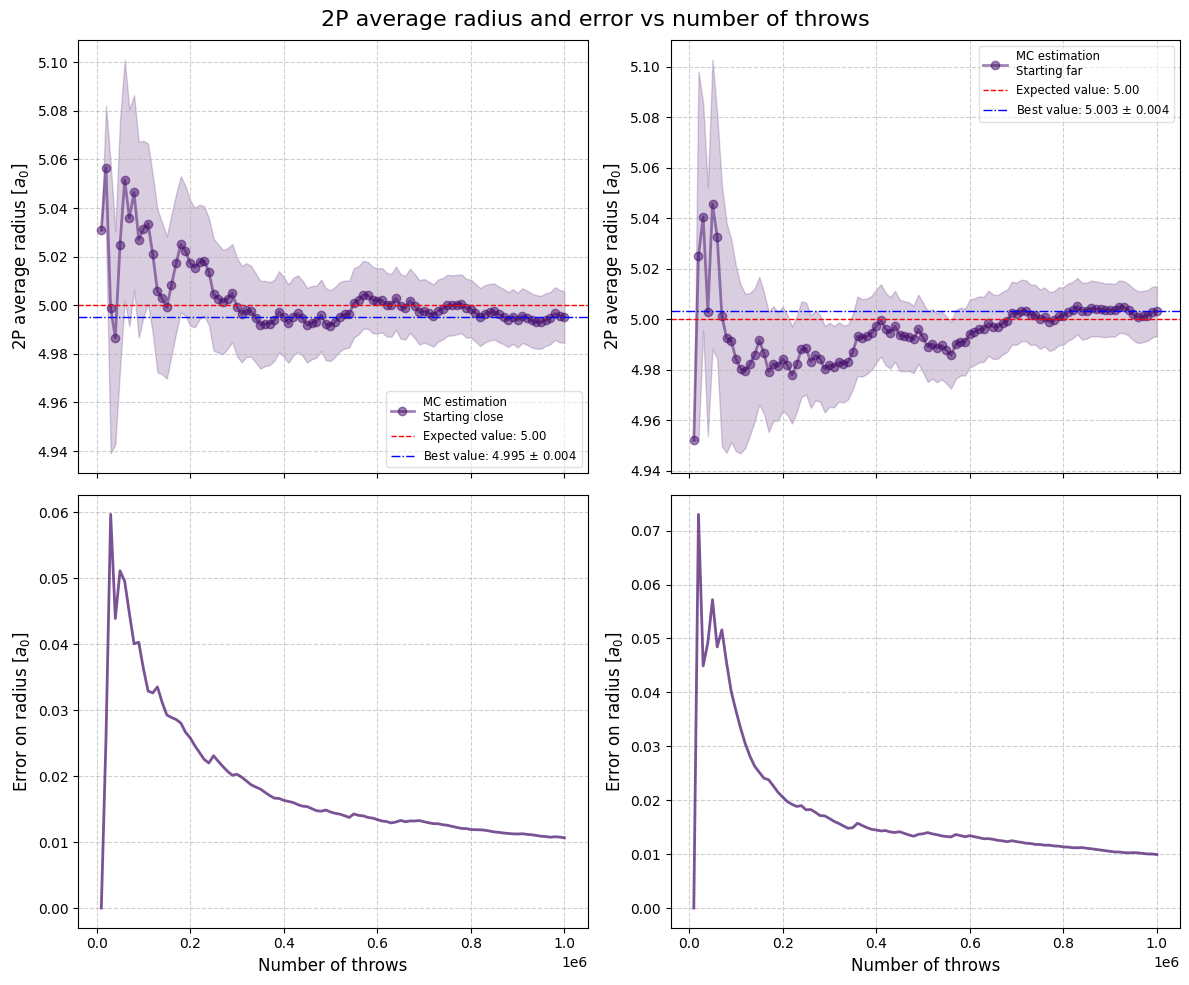

In [3]:
x_2p, y_2p, error_2p = np.loadtxt("output_average_2p_uniform.data", usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_2p_far, y_2p_far, error_2p_far = np.loadtxt("output_average_2p_far_uniform.data", usecols=(0, 1, 2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor('white')  

expected_val = 5.
best_val_near = y_2p[99]
best_val_far = y_2p_far[99]

# Plot 2P - Near

ax[0, 0].plot(x_2p, y_2p, marker='o', color=color2, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_2p, y_2p+error_2p,y_2p-error_2p, color=color2, alpha=0.2)
ax[0, 0].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 0].axhline(
    y=best_val_near,
    color=ref_color_2,
    linestyle='-.',
    linewidth=1,
    label=rf'Best value: {best_val_near:.3f} $\pm$ {error_1s[99]:.3f}')
ax[0, 0].set_ylabel('2P average radius [$a_0$]')
ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].legend(loc='lower right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Plot 2P - Far
ax[0, 1].plot(x_2p_far, y_2p_far, marker='o', color=color2, alpha=0.5, label='MC estimation \nStarting far')
ax[0, 1].fill_between(x_2p_far, y_2p_far+error_2p_far,y_2p_far-error_2p_far, color=color2, alpha=0.2)
ax[0, 1].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 1].axhline(y=best_val_far, color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {best_val_far:.3f} $\pm$ {error_1s_far[99]:.3f}')
ax[0, 1].set_ylabel('2P average radius [$a_0$]')
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[0, 1].grid(True, linestyle='--', alpha=0.6)
ax[0, 1].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Errori
ax[1, 0].plot(x_2p, error_2p, '-', color=color2, alpha=0.7)
ax[1, 0].set_xlabel('Number of throws')
ax[1, 0].set_ylabel('Error on radius [$a_0$]')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)

ax[1, 1].plot(x_2p_far, error_2p_far, '-', color=color2, alpha=0.7)
ax[1, 1].set_xlabel('Number of throws')
ax[1, 1].set_ylabel('Error on radius [$a_0$]')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('2P average radius and error vs number of throws', fontsize=16)
plt.tight_layout()
plt.show()

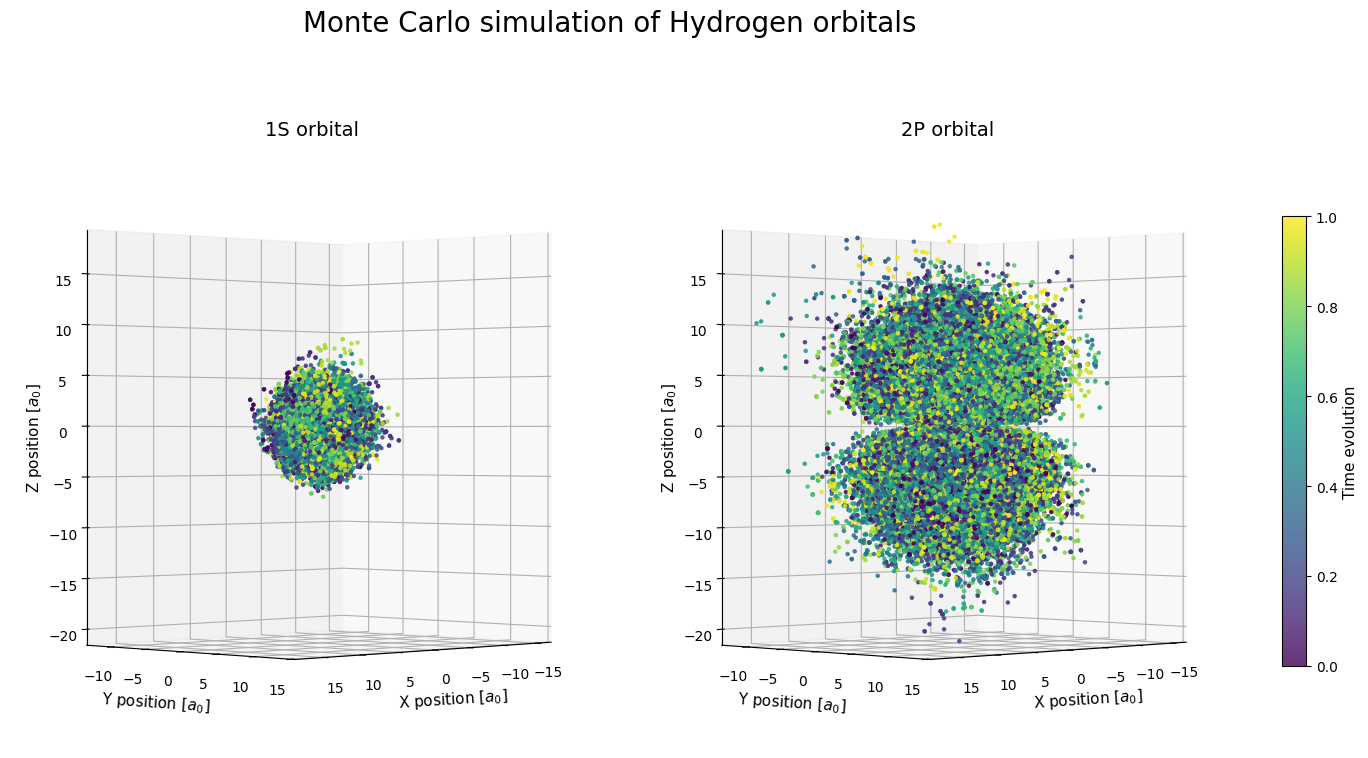

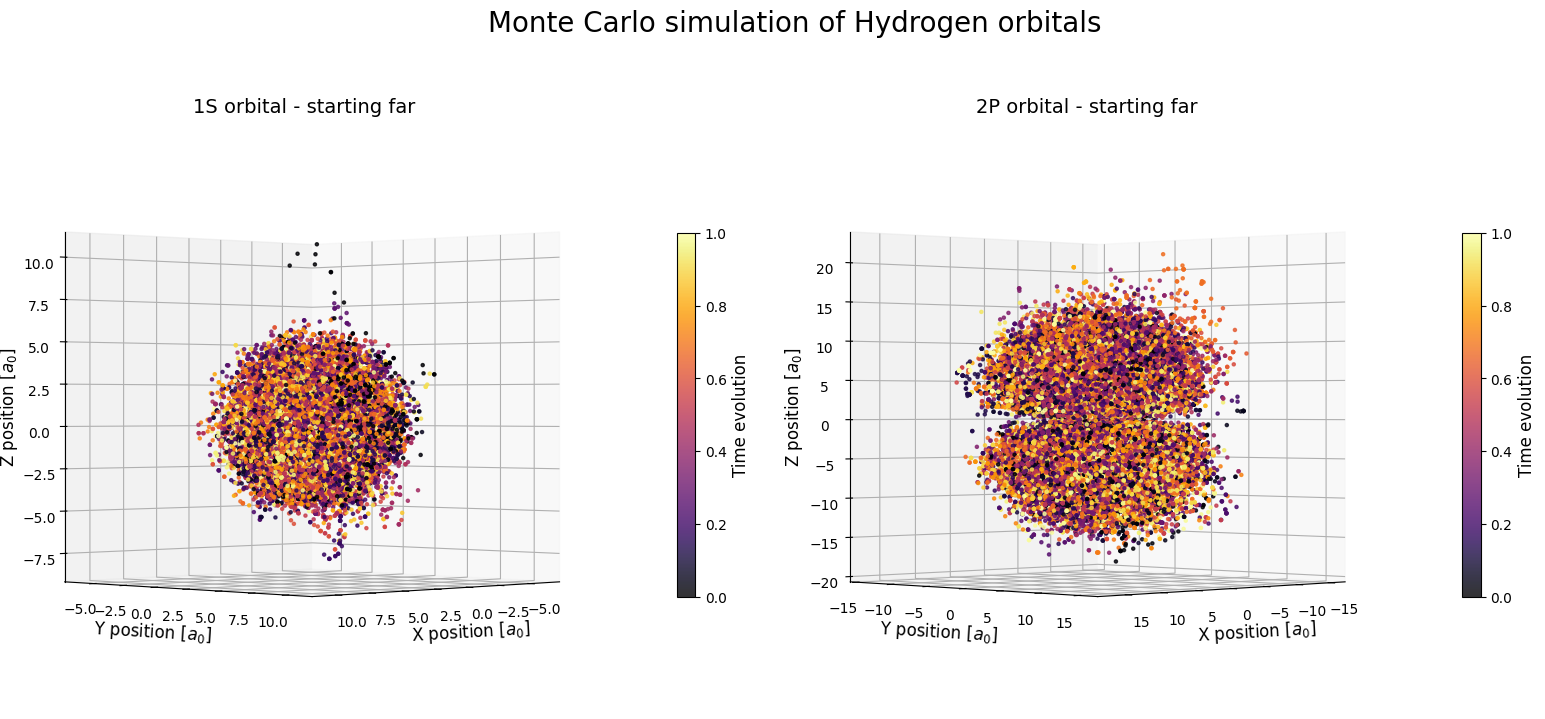

In [5]:
data_1s = np.loadtxt("positions_1s_uniform.data")
data_2p = np.loadtxt("positions_2p_uniform.data")

all_data = np.vstack((data_1s, data_2p))
x_min, x_max = all_data[:, 0].min(), all_data[:, 0].max()
y_min, y_max = all_data[:, 1].min(), all_data[:, 1].max()
z_min, z_max = all_data[:, 2].min(), all_data[:, 2].max()

def set_equal_limits_and_aspect(ax):
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect([x_max - x_min, y_max - y_min, z_max - z_min])

plt.style.use('default')
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

cmap = "viridis"
colors_1s = np.linspace(0, 1, len(data_1s))
colors_2p = np.linspace(0, 1, len(data_2p))

ax1 = fig.add_subplot(gs[0], projection='3d')
sc1 = ax1.scatter(data_1s[:, 0], data_1s[:, 1], data_1s[:, 2],
                  c=colors_1s, cmap=cmap, s=5, alpha=0.8)
ax1.set_title("1S orbital", fontsize=14, color='black')
ax1.set_xlabel("X position [$a_0$]", fontsize=11)
ax1.set_ylabel("Y position [$a_0$]", fontsize=11)
ax1.set_zlabel("Z position [$a_0$]", fontsize=11)
ax1.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax1)

ax2 = fig.add_subplot(gs[1], projection='3d')
sc2 = ax2.scatter(data_2p[:, 0], data_2p[:, 1], data_2p[:, 2],
                  c=colors_2p, cmap=cmap, s=5, alpha=0.8)
ax2.set_title("2P orbital", fontsize=14, color='black')
ax2.set_xlabel("X position [$a_0$]", fontsize=11)
ax2.set_ylabel("Y position [$a_0$]", fontsize=11)
ax2.set_zlabel("Z position [$a_0$]", fontsize=11)
ax2.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax2)

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(sc2, cax=cbar_ax)
cbar.set_label("Time evolution", fontsize=11)

plt.suptitle("Monte Carlo simulation of Hydrogen orbitals", fontsize=20)
plt.subplots_adjust(wspace=0.05, right=0.9)
plt.show()

# Starting far
#==============================================================================
data_1s_far = np.loadtxt("positions_1s_far_uniform.data")
data_2p_far = np.loadtxt("positions_2p_far_uniform.data")

fig2 = plt.figure(figsize=(16, 8))
ax3 = fig2.add_subplot(121, projection='3d')
colors_1s_far = np.linspace(0, 1, len(data_1s_far))
sc3 = ax3.scatter(data_1s_far[:, 0], data_1s_far[:, 1], data_1s_far[:, 2], 
                  c=colors_1s_far, cmap="inferno", s=5, alpha=0.8)

ax3.set_box_aspect((1, 1, 1)) 
cbar3 = fig2.colorbar(sc3, ax=ax3, shrink=0.5, pad=0.1)
cbar3.set_label("Time evolution", fontsize=12)

ax3.set_xlabel("X position [$a_0$]", fontsize=12)
ax3.set_ylabel("Y position [$a_0$]", fontsize=12)
ax3.set_zlabel("Z position [$a_0$]", fontsize=12)
ax3.set_title("1S orbital - starting far", fontsize=14)
ax3.view_init(elev=0, azim=45)

ax4 = fig2.add_subplot(122, projection='3d')
colors_2p_far = np.linspace(0, 1, len(data_2p_far))
sc4 = ax4.scatter(data_2p_far[:, 0], data_2p_far[:, 1], data_2p_far[:, 2], 
                  c=colors_2p_far, cmap="inferno", s=5, alpha=0.8)

ax4.set_box_aspect((1, 1, 1))
cbar4 = fig2.colorbar(sc4, ax=ax4, shrink=0.5, pad=0.1)
cbar4.set_label("Time evolution", fontsize=12)

ax4.set_xlabel("X position [$a_0$]", fontsize=12)
ax4.set_ylabel("Y position [$a_0$]", fontsize=12)
ax4.set_zlabel("Z position [$a_0$]", fontsize=12)
ax4.set_title("2P orbital - starting far ", fontsize=14)
ax4.view_init(elev=0, azim=45)

plt.suptitle("Monte Carlo simulation of Hydrogen orbitals", fontsize=20)
plt.tight_layout()
plt.show()